## Module 23: Principal Component Analysis

### Dataset: Wine Quality Dataset

In [13]:
# Done for you

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)

df = wine.frame

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### TODO 1: Explore the Dataset

In [6]:
# TODO

# Display dataset shape

# Display first few rows

# Display data types

# Display class distribution
print(df.shape)
print(df.head(5))
print(df.dtypes)
print(df.describe())
print(df['target'].value_counts())


(178, 14)
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0

### TODO 2 : Feature Correlation

                               alcohol  malic_acid       ash  \
alcohol                       1.000000    0.094397  0.211545   
malic_acid                    0.094397    1.000000  0.164045   
ash                           0.211545    0.164045  1.000000   
alcalinity_of_ash            -0.310235    0.288500  0.443367   
magnesium                     0.270798   -0.054575  0.286587   
total_phenols                 0.289101   -0.335167  0.128980   
flavanoids                    0.236815   -0.411007  0.115077   
nonflavanoid_phenols         -0.155929    0.292977  0.186230   
proanthocyanins               0.136698   -0.220746  0.009652   
color_intensity               0.546364    0.248985  0.258887   
hue                          -0.071747   -0.561296 -0.074667   
od280/od315_of_diluted_wines  0.072343   -0.368710  0.003911   
proline                       0.643720   -0.192011  0.223626   
target                       -0.328222    0.437776 -0.049643   

                              alcalinit

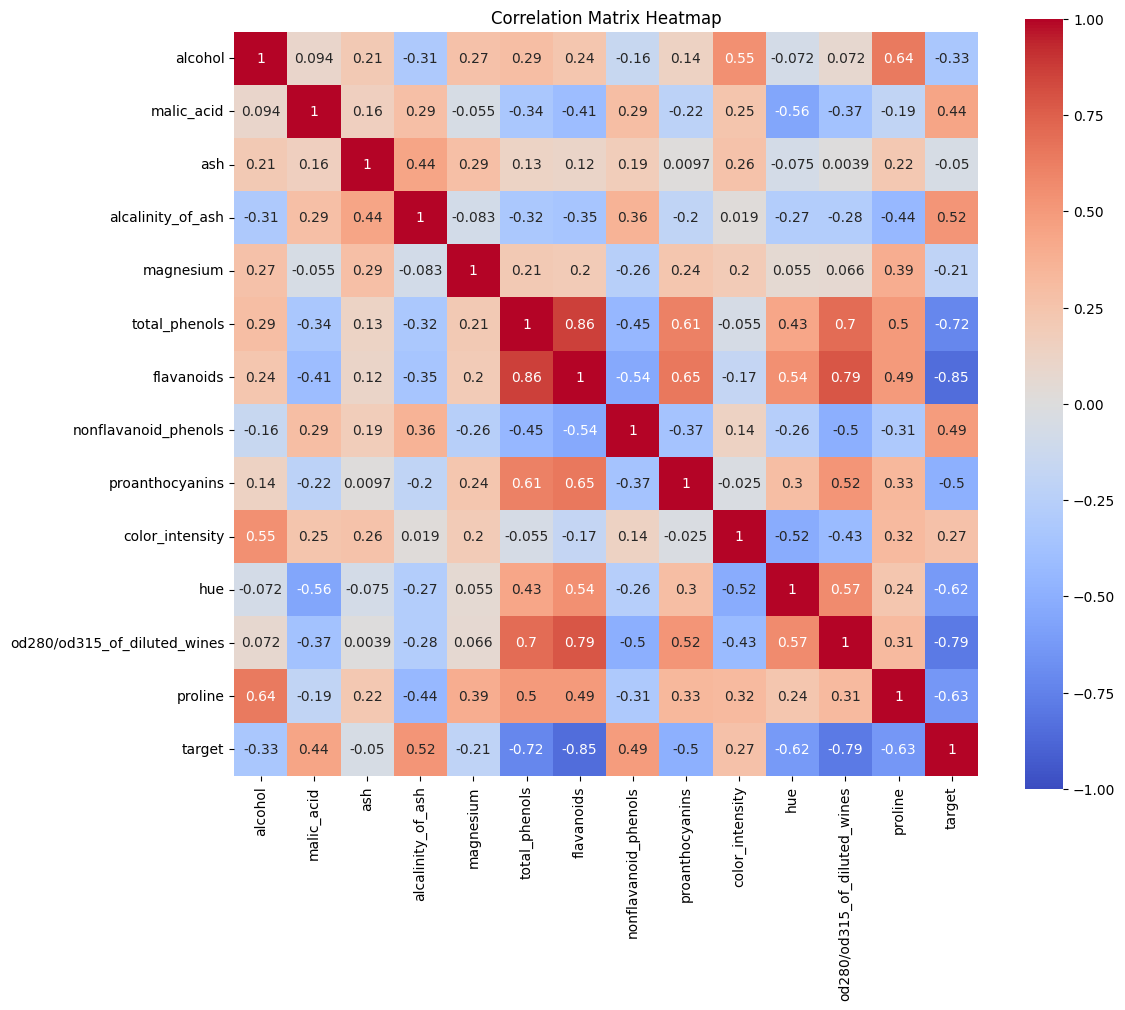

In [11]:
# TODO

# Calculate correlation matrix

# Display highly correlated features
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            square=True)

plt.title("Correlation Matrix Heatmap")
plt.show()

### TODO 3 : Standardization

In [26]:
from sklearn.preprocessing import StandardScaler

# TODO

# Separate X and y
X = df.drop('target', axis=1)
y = df['target']
# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### TODO 4 : Apply PCA

In [27]:
from sklearn.decomposition import PCA

# TODO

# Apply PCA
np.set_printoptions(suppress=True)

pca_full = PCA(n_components=None)
X_pac_full = pca_full.fit_transform(X_scaled)

# Display explained variance ratio
explained = pca_full.explained_variance_ratio_
explained


array([0.36198848, 0.1920749 , 0.11123631, 0.0706903 , 0.06563294,
       0.04935823, 0.04238679, 0.02680749, 0.02222153, 0.01930019,
       0.01736836, 0.01298233, 0.00795215])

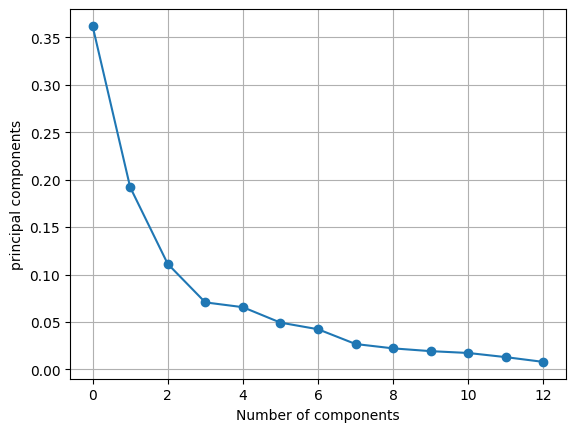

In [28]:
# Display number of principal components

plt.plot(explained, marker='o')
plt.xlabel("Number of components")
plt.ylabel("principal components")
plt.grid()
plt.show()

### TODO 5 : Cumulative Variance

In [33]:
# TODO

# Calculate cumulative variance

cum_variance = np.cumsum(explained)
cum_variance


array([0.36198848, 0.55406338, 0.66529969, 0.73598999, 0.80162293,
       0.85098116, 0.89336795, 0.92017544, 0.94239698, 0.96169717,
       0.97906553, 0.99204785, 1.        ])

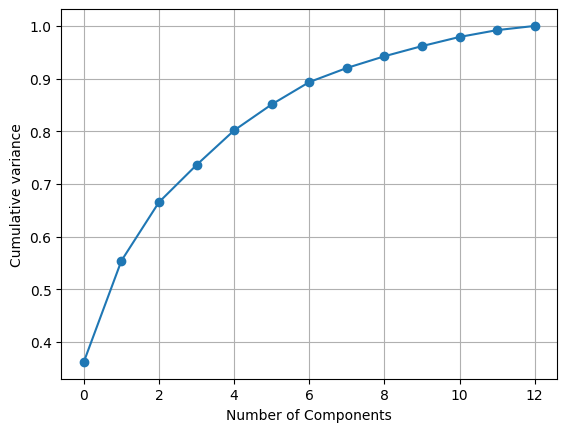

In [32]:
# Plot cumulative variance graph

plt.plot(cum_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative variance")
plt.grid()
plt.show()

### TODO 6 : Logistic Regression WITHOUT PCA

In [30]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

# TODO using pipeline perform these tasks

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# StandardScaler

# Logistic Regression
pipe_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500))
])

# Calculate Accuracy
pipe_no_pca.fit(X_train, y_train)
pred_no_pca = pipe_no_pca.predict(X_test)

acc_no_pca = accuracy_score(y_test, pred_no_pca)

In [31]:
print("Accuracy: ", acc_no_pca)

Accuracy:  0.9722222222222222


### TODO 7 : Logistic Regression WITH PCA

In [38]:
# TODO

# StandardScaler

# PCA(95% rakhte joto gula component lage totogulo use kore)
# Logistic Regression
# Calculate Accuracy

pipe_with_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=9)),
    ("clf", LogisticRegression(max_iter=500))
])

pipe_with_pca.fit(X_train, y_train)
pred_with_pca = pipe_with_pca.predict(X_test)

acc_with_pca = accuracy_score(y_test, pred_with_pca)

In [39]:
print("Accuracy : ", acc_with_pca)

Accuracy :  0.9722222222222222


### TODO 8 : Compare Results

In [40]:
# TODO

# Create a small comparison table
# Without PCA
# With PCA
# Accuracy
# Number of Features

print(f"Accuracy without PCA :{acc_no_pca}, accuracy with PCA :{acc_with_pca}")

Accuracy without PCA :0.9722222222222222, accuracy with PCA :0.9722222222222222


In [42]:
comparison = pd.DataFrame({
    "Method" : ["Without PCA", "With PCA"],
    "Accuracy" : [round(acc_no_pca, 4), round(acc_with_pca, 4)],
    "Number of Features" : [X_train.shape[1], 9]
})

print(comparison)

        Method  Accuracy  Number of Features
0  Without PCA    0.9722                  13
1     With PCA    0.9722                   9


Q: In this dataset, would you recomment PCA? Justify and explain your observation


A: **Yes, I would recommend PCA for this dataset.**

In this experiment, applying PCA reduced the number of features from 13 to 9 while maintaining the same classification accuracy (97.22%). This indicates that PCA successfully removed redundant information without affecting the model's predictive performance. Using fewer features makes the model simpler, reduces computational cost, and can improve efficiency. Therefore, PCA is a good choice for this dataset because it achieves dimensionality reduction without sacrificing accuracy.